# Examen Data Science & AI

| | |
| :--- | :--- |
| **Examenreeks** | Voorbeeldexamen |
| **Student:** | VUL HIER JE NAAM IN |
| **Studentennummer:** | VUL HIER JE STUDENTENNUMMER IN |
| **Datum & uur:** | EXAMENDATUM, STARTUUR |
| **Klasgroep:** | VUL HIER JE KLASGROEP IN |
| **IOEM-student:** | NEE |

Add code cells where necessary to work out the questions. 

**CAUTION!** The contents of the code blocks are not considered answers! Only what you write down in the Markdown cells provided for that purpose counts as an answer! The content of the code blocks serves only to substantiate your answer so that we can see how you arrived at your answer if it would not match the expected outcome.

**DON'T FORGET THE SCREEN CAPTURE!!**

!! The exam will be in dutch for all students not enrolled in the IC !!

In [420]:
# Importeren van de nodige packages
# Vul zelf aan met extra packages als dit nodig is voor de oefeningen!
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

## Question 1

The diameter of pistons produced in a factory are _D_ cm where _D_ ~ Nor(13.4, 0.12)

(1) The tolerance specified for the pistons is that the diameter needs to be at least 13.35 cm and not more than 13.5 cm. What proportion of the production in the factory meets these tolerance limits?  

In [421]:
mu = 13.4
s = 0.12
p_valid_piston = stats.norm.sf(x=13.35, loc=mu, scale=s) - stats.norm.sf(x=13.5, loc=mu, scale=s)
print(p_valid_piston)

0.45921049952566867


45.92% of pistons meet the tolerance limit.

(2) Three pistons are chosen at random. What is the probability that none of them meet the tolerance limits  

In [422]:
no_valid_pistons = (1- p_valid_piston)**3
print(no_valid_pistons)

0.15815566527086766


The chance that no piston meets the tolerance limits is 15.81%.

(3) A sample of 20 pistons is taken at random. The mean value for the diameter is found to be 13.43 cm. Test at the 5% significance level whether any modifications have been made to the machine producing the pistons.

In [423]:
H0 = "There is no evidence to reject that the mean is 13.4cm"
H1 = "There is evidence that the machine has been modified."

alpha = 0.05
sample_mean = 13.43
p = stats.norm.sf(sample_mean, loc=mu, scale = s / 20**0.5)
print(p)
print(H0 if p < alpha / 2 else H1)

0.13177623864149146
There is evidence that the machine has been modified.


There is evidence that the machine might have been modified.

## Question 2

The number of employees on the payroll at a food processing company is recorded at the beginning of each month.
These data are given below.

1. Give the data types of both columns
2. Convert the 'date' column to datetime type. Even if this fails you can continue working.
3. Create the following plot.

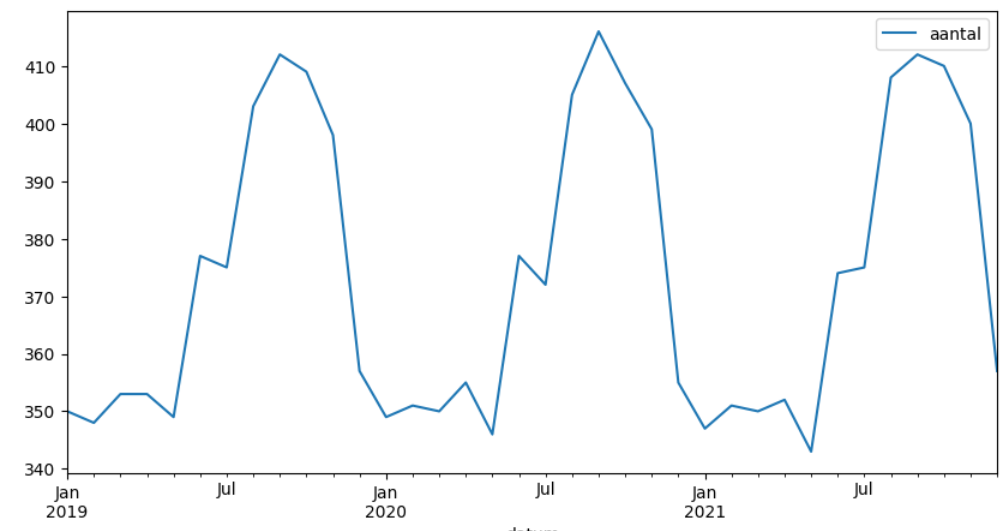

4. Make a forecast for the first four months of the next year using the most appropriate method. Explain why you chose this method.
5. Make a plot including the forecast.
6. Make the following calculations
- 6.1 Calculate the average number of employees in 2020
- 6.2 How many months did the company have more than 400 employees?




In [424]:
dfemployees = pd.DataFrame(data={
    'recording_date': ['2019/01/01', '2019/02/01', '2019/03/01', '2019/04/01', '2019/05/01', '2019/06/01', '2019/07/01', '2019/08/01', '2019/09/01', '2019/10/01', '2019/11/01', '2019/12/01', '2020/01/01', '2020/02/01', '2020/03/01', '2020/04/01', '2020/05/01', '2020/06/01', '2020/07/01', '2020/08/01', '2020/09/01', '2020/10/01', '2020/11/01', '2020/12/01', '2021/01/01', '2021/02/01', '2021/03/01', '2021/04/01', '2021/05/01', '2021/06/01', '2021/07/01', '2021/08/01', '2021/09/01', '2021/10/01', '2021/11/01', '2021/12/01'],
    'number': [350,348,353,353,349,377,375,403,412,409,398,357,349,351,350,355,346,377,372,405,416,407,399,355,347,351,350,352,343,374,375,408,412,410,400,357]
})

In [425]:
# 1. Give the data types of both columns
dfemployees.dtypes

recording_date      str
number            int64
dtype: object

recording_date is een string en number is een integer

In [426]:
# 2. Convert the 'date' column to datetime type. Even if this fails you can continue working.
dfemployees['recording_date'] = pd.to_datetime(dfemployees['recording_date'])
dfemployees = dfemployees.set_index('recording_date')

<Axes: xlabel='recording_date'>

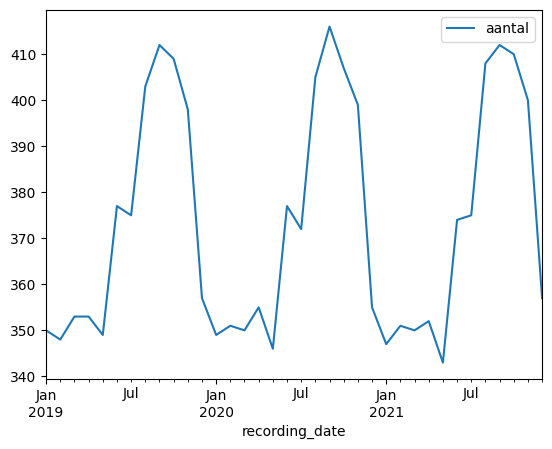

In [427]:
# 3. Create the plot.
dfemployees.plot(y='number', label='aantal')

In [428]:
# 4. Make a forecast for the first four months of the next year using the most appropriate method. Explain why you chose this method.

from statsmodels.tsa.holtwinters import ExponentialSmoothing
model = ExponentialSmoothing(dfemployees['number'], seasonal='add', seasonal_periods=12).fit()
fcast = model.forecast(4)

c:\Users\jelle\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Er is een duidelijke seasonal component dus de Holt-Winters methode is de beste methode om hier toe te passen.
De forecast voorspelt de volgende waarden:
- Januari 2022: 348.67
- Februari 2022: 350
- Maart 2022: 351
- April 2022: 353.33

<Axes: xlabel='recording_date'>

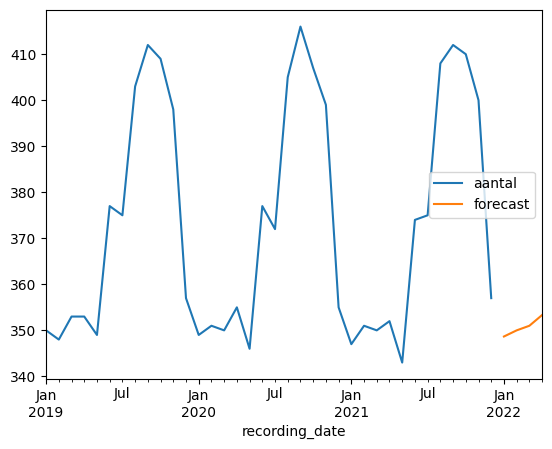

In [429]:
# 5. Make a plot including the forecast.
dfemployees.plot(y='number', label='aantal')
fcast.plot(legend=True, label='forecast')


In [430]:
# 6. Make the following calculations
# - 6.1 Calculate the average number of employees in 2020
data_2020 = dfemployees["2020-01-01" : "2020-12-01"]
avg_number_2020 = data_2020['number'].mean()
print(avg_number_2020)

373.5


Het gemiddelde aantal werknemers in 2020 was 373.5.

In [431]:
# - 6.2 How many months did the company have more than 400 employees?
meer_dan_400 = dfemployees[dfemployees['number'] > 400]
print(meer_dan_400.size)

9


Er waren 9 maanden waarin het bedrijf meer dan 400 werknemers had.

## Question 3

In the Flanders Travel Behavior Survey (2021-2022) (Onderzoek Verplaatsingsgedrag Vlaanderen), we find the following figures related to the distribution of driver's license ownership by net income at the person level for persons aged 18 and over (excluding schoolchildren and students).  Is there a relationship between income and whether or not one has a driver's license?

1. What hypothesis test will you apply to answer this research question? Be as specific as possible!
2. Formulate the null hypothesis and the alternative hypothesis
3. Calculate the appropriate test statistic (test statistic) for this test. Provide the symbol and value
4. Calculate the p-value
5. Draw a conclusion based on the previous step and formulate an answer to the research question.
6. What percentage of those surveyed do not have a driver's license?

In [432]:
dfdriverlicense = pd.DataFrame(data={
    'income': ['0 - 1000 EUR', '1001 - 1500 EUR', '1501 - 2000 EUR', '2001 - 2500 EUR', '2501 - 3000 EUR', '>3000 EUR', 'does not want to answer this question'],
    'yes': [149, 469, 800, 653, 325, 270, 230],
    'no': [61, 157, 55, 20, 10, 4, 51]}).set_index('income')
dfdriverlicense.head(10)

,yes,no
income,,
0 - 1000 EUR,149,61
1001 - 1500 EUR,469,157
1501 - 2000 EUR,800,55
2001 - 2500 EUR,653,20
2501 - 3000 EUR,325,10
>3000 EUR,270,4
does not want to answer this question,230,51


In [433]:
# 1. What hypothesis test will you apply to answer this research question? Be as specific as possible!
print(f"Chi-kwadraat test voor onafhankelijkheid")

Chi-kwadraat test voor onafhankelijkheid


Ik ga hier de T-test voor independent samples gebruiken.

In [434]:
# 2. Formulate the null hypothesis and the alternative hypothesis
H0 = 'Er is niet genoeg bewijs om aan te tonen dat een hoger inkomen een grotere kans geeft op het hebben van een rijbewijs.'
H1 = 'Er is genoeg bewijs om aan te tonen dat een hoger inkomen een grotere kans geeft op het hebben van een rijbewijs.'


In [435]:
# 3. Calculate the appropriate test statistic (test statistic) for this test. Provide the symbol and value
# 4. Calculate the p-value
dfdriverlicense = dfdriverlicense[:'does not want to answer this question']
dfdriverlicense.head(10)

chi2, p, dof, expected = stats.chi2_contingency(dfdriverlicense)
print(chi2)
print(p)

321.23310143141657
2.29655378022715e-66


$\chi^2 = 321.2331 $ <br>
$p = 2.29655378022715e-66$

In [436]:
# 5. Draw a conclusion based on the previous step and formulate an answer to the research question.
print(H0 if alpha > 0.05 else H1)

Er is genoeg bewijs om aan te tonen dat een hoger inkomen een grotere kans geeft op het hebben van een rijbewijs.


In [437]:
# 6. What percentage of those surveyed do not have a driver's license?
percentage = dfdriverlicense.no.sum() / (dfdriverlicense.yes.sum() + dfdriverlicense.no.sum())
print(np.round(percentage * 100, 2))


11.0


## Question 4

Below are the restaurant scores for a number of New York City (NYC) and Long Island (LI) restaurants.

1. First, based on the scores for *eat*, *decor* and *service*, calculate the *total score*. **If you cannot calculate the total score, continue working with the score for food.**
2. Create the plot below.

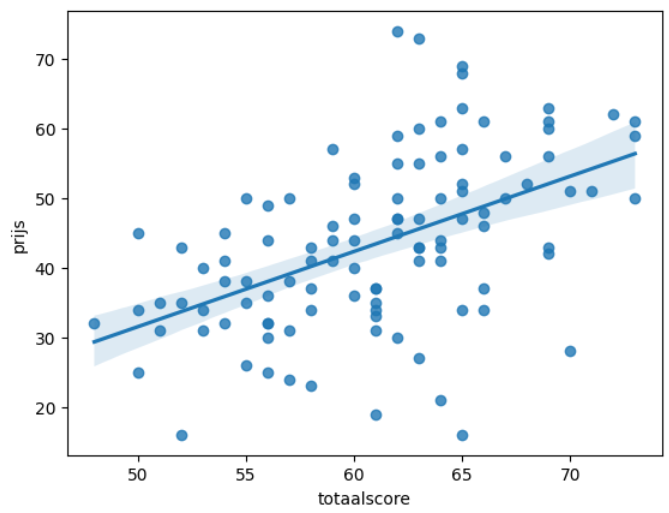

3. Use linear regression to try to predict the *price* based on the *total score*. Give the equation of the regression equation.
4. Give the estimated *price* for a *total score* = 70.
5. Calculate the correlation coefficient (symbol + value).
6. Give the interpretation for the value of the correlation coefficient.
7. List the number, minimum, maximum, mean, standard deviation, ... in the columns of quantitative variables.
8. The coefficient of variation is a dispersion measure that is independent of the unit in which data are expressed and is defined as the standard deviation divided by the mean. Calculate the coefficient of variation for *the score for eating*.
9. How many restaurants are there in New York City with a *price* higher than $65 (not including $65)?
10. Are *prices* in New York City significantly ($alpha = 0.05$) higher than in Long Island?

    - What statistical test will you use to determine this?
    - Formulate the null hypothesis and the alternative hypothesis
    - Calculate the excess probability $p$
    - Draw a conclusion based on this value and answer the research question.

In [438]:
dfrestaurants = pd.DataFrame(
    data={'restaurantname': ["101","12th St. Bar & Grill","202 Café","212","24 Prince","26 Seats","360","41 Greenwich Avenue","44","44 X Hell's Kitchen","5 Ninth","71 Irving Place","718","A.O.C.","A.O.C. Bedford","Abboccato","Abigael's","Above","Adrienne's Pizzabar","Aesop's Tables","Agata & Valentina Ristorante","Agave","Agnanti","Aix Brasserie","Aja","Aji Sushi","Areo","Bouley, Upstairs","Casa Mono","Cesca","Coals","Etats-Unis","Gari","Henry's End","ino","inoteca","Joya","Lupa","MarkJoseph Steakhouse","Noodle Pudding","Norma's","Osaka","Pearl Oyster Bar","Piccola Venezia","Po","Scalinatella","Sparks Steak House","Spigolo","Sushi Ann","Sushi Sen-nin","Tommaso","Wolfgang's Steakhouse","Yakitori Totto","105 Harbor","1770 House Restaurant & Inn","25 East American Bistro","56th Fighter Group","Abel Conklin's","Adirondack Grill","Akbar","Albert's Mandarin Gourmet","Allison's Ristorante","Almond","Amici","Aqua Blue Bar & Grill","Argyle Grill & Tavern","Ariana","Ayhan's Fish Kebab","Ayhan's Mediterranean Café","B. Smith's","Baang Café & Bar","Babylon Carriage House","Bamboo Restaurant & Sushi","Barney's","Barolo","Basil Leaf Café","Bay & Main","Bayou, The","Bayport House, The","Bayview Inn & Restaurant","Beacon","Bedlam Street Fish & Clam","Bella Vita City Grill","Bellport, The","Benihana","Benny's Ristorante","Maureen & Daughters Kitchen","Minami","Mirko's","Nisen","Palm","Plaza Café","Robert's","Rothmann's Steakhouse","Royal Tangra Masala","Sempre Vivolo","Soigne","Sole","Starr Boggs","Steve's Piccola Bussola","Stonewalls","Tellers American Chophouse","Trattoria Diane","Vine Street Café","Vintage Prime Steakhouse","Yuki's Palette"],
    'location': ["NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI"],
    'food': [20,21,21,17,18,23,23,18,20,21,20,19,22,19,23,23,20,18,24,22,18,19,24,21,20,21,25,25,25,23,25,25,26,25,24,23,25,25,25,25,25,25,26,25,25,25,25,25,25,25,25,25,25,20,24,16,14,22,16,19,23,19,21,22,18,21,20,20,18,16,22,21,20,26,24,18,19,22,21,24,20,22,21,24,17,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25],
    'decor': [18,19,17,17,17,16,15,18,22,18,22,17,19,16,21,20,16,19,17,18,16,19,15,21,23,14,20,16,18,21,17,16,17,14,14,18,19,18,17,18,20,17,14,17,16,17,19,16,17,15,18,20,19,22,25,20,21,17,21,17,18,19,15,18,17,21,17,17,15,23,23,24,18,23,20,17,15,16,21,21,19,19,17,19,17,18,19,21,21,20,18,21,21,22,14,22,24,15,24,15,21,26,21,15,21,15],
    'service': [17,20,18,16,15,19,19,19,18,19,17,16,19,16,21,21,18,18,17,20,14,18,19,20,20,20,21,18,20,21,19,23,19,24,18,20,20,21,23,22,21,20,19,23,21,21,21,21,21,20,22,20,20,20,23,17,16,21,16,18,22,21,18,21,17,19,20,19,17,17,19,18,18,24,22,19,18,18,20,24,18,21,20,21,19,24,21,24,23,21,23,24,21,22,18,24,24,21,20,21,23,22,22,23,23,21],
    'price': [38,36,32,45,34,37,38,35,52,43,57,16,40,35,51,61,45,50,23,44,32,36,34,59,43,26,48,46,47,57,19,56,74,43,25,37,21,50,63,34,37,30,41,52,47,73,68,55,60,53,47,69,44,50,62,40,31,47,31,32,27,44,41,33,43,35,31,30,25,49,43,41,44,59,46,38,35,32,47,42,50,45,41,41,34,50,16,28,63,34,61,51,56,60,24,51,50,34,56,37,43,61,52,55,61,31]})


In [439]:
# 1. First, based on the scores for *eat*, *decor* and *service*, calculate the *total score*. **If you cannot calculate the total score, continue working with the score for food.**
dfrestaurants['total_score'] = dfrestaurants['food'] + dfrestaurants['decor'] + dfrestaurants['service']
dfrestaurants.head()

,restaurantname,location,food,decor,service,price,total_score
0,101,NYC,20,18,17,38,55
1,12th St. Bar & Grill,NYC,21,19,20,36,60
2,202 Café,NYC,21,17,18,32,56
3,212,NYC,17,17,16,45,50
4,24 Prince,NYC,18,17,15,34,50


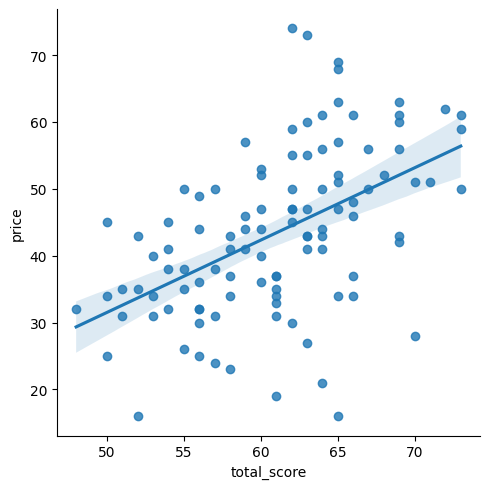

In [440]:
# 2. Create the plot below.
sns.lmplot(data=dfrestaurants, x='total_score', y='price')

In [441]:
# 3. Use linear regression to try to predict the *price* based on the *total score*. Give the equation of the regression equation.
beta1, beta0 = np.polyfit(dfrestaurants.total_score, dfrestaurants.price, deg=1)
print(f"y = {beta0} + {beta1} * x")


y = -22.56883311935267 + 1.081716366690083 * x


In [442]:
# 4. Give the estimated *price* for a *total score* = 70.
price_score_70 = beta0 + beta1 * 70
print(f'De prijs voor een totale score van 70 zal rond €{np.round(price_score_70, 2)} liggen.')

De prijs voor een totale score van 70 zal rond €53.15 liggen.


In [443]:
# 5. Calculate the correlation coefficient (symbol + value).
price_r = np.corrcoef(dfrestaurants.total_score, dfrestaurants.price)[0][1]

print(f"R = {price_r}")

R = 0.5035321564330562


In [444]:
# 6. Give the interpretation for the value of the correlation coefficient.
print(f"Aangezien R net boven de 0.5 ligt, is er een moderate relatie tussen de totale score en de prijs van het restaurant.")

Aangezien R net boven de 0.5 ligt, is er een moderate relatie tussen de totale score en de prijs van het restaurant.


In [445]:
# 7. List the number, minimum, maximum, mean, standard deviation, ... in the columns of quantitative variables.
dfrestaurants.describe()

,food,decor,service,price,total_score
count,106.000000,106.000000,106.000000,106.000000,106.000000
mean,22.471698,18.528302,19.990566,43.405660,60.990566
std,2.902241,2.712256,2.261459,12.411806,5.777617
min,14.000000,14.000000,14.000000,16.000000,48.000000
25%,20.000000,17.000000,18.000000,34.000000,56.250000
50%,23.500000,18.000000,20.000000,43.000000,61.500000
75%,25.000000,21.000000,21.000000,51.000000,65.000000
max,26.000000,26.000000,24.000000,74.000000,73.000000


In [446]:
# 8. The coefficient of variation is a dispersion measure that is independent of the unit in which data are expressed and is defined as the standard deviation divided by the mean. Calculate the coefficient of variation for *the score for eating*.
coeff_var = dfrestaurants['food'].std() / dfrestaurants['food'].mean()
print(f"The coefficient of variation is {coeff_var}")

The coefficient of variation is 0.12915092815765825


In [447]:
# 9. How many restaurants are there in New York City with a *price* higher than $65 (not including $65)?
nyc_higher_65 = dfrestaurants.query("(location=='NYC') and (price > 65)")
print(f'Er zijn {nyc_higher_65['restaurantname'].count()} restaurants in New York City met een prijs boven de $65')


Er zijn 4 restaurants in New York City met een prijs boven de $65


In [448]:
#10. Are *prices* in New York City significantly ($alpha = 0.05$) higher than in Long Island?

#    - What statistical test will you use to determine this?
#    - Formulate the null hypothesis and the alternative hypothesis
#    - Calculate the excess probability $p$
#    - Draw a conclusion based on this value and answer the research question.



In [449]:
#    - What statistical test will you use to determine this?
print("De T-test voor independent samples.")

De T-test voor independent samples.


In [450]:
H0 = 'Er is niet genoeg bewijs om te zeggen dat de de prijzen in New York City significant hoger zijn dan in Long Island.'
H1 = 'Er is bewijs dat de prijzen in New York City significant hoger zijn dan die in Long Island.'

print(f"Null hypothesis: {H0}")
print(f"Alternative hypothesis: {H1}")

Null hypothesis: Er is niet genoeg bewijs om te zeggen dat de de prijzen in New York City significant hoger zijn dan in Long Island.
Alternative hypothesis: Er is bewijs dat de prijzen in New York City significant hoger zijn dan die in Long Island.


In [451]:
dfrestaurants_nyc = dfrestaurants[dfrestaurants['location'] == 'NYC']
dfrestaurants_li = dfrestaurants[dfrestaurants['location'] == 'LI']

t_stat, p_value = stats.ttest_ind(a=dfrestaurants_nyc['price'], b=dfrestaurants_li['price'], equal_var=False, alternative='greater')
print(f'p-value = {p_value}')

print(H0 if p_value > 0.05 else H1)

p-value = 0.27990194701641724
Er is niet genoeg bewijs om te zeggen dat de de prijzen in New York City significant hoger zijn dan in Long Island.
